#Step-1 : Import Libraries

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


#Step-2 : Create Our Dataset

In [2]:
# Set random seed so that we get the same dataset every time
np.random.seed(42)

# Number of students
num_students = 1000

# Generate student data
study_hours = np.random.uniform(1, 10, num_students)
attendance = np.random.uniform(50, 100, num_students)
previous_score = np.random.uniform(40, 100, num_students)
assignment_score = np.random.uniform(40, 100, num_students)
sleep_hours = np.random.uniform(4, 9, num_students)
participation_score = np.random.uniform(40, 100, num_students)

# Generate final score using a realistic relationship
noise = np.random.normal(0, 4, num_students)

final_score = (
    2.5 * study_hours
    + 0.25 * attendance
    + 0.35 * previous_score
    + 0.20 * assignment_score
    + 0.8 * sleep_hours
    + 0.15 * participation_score
    + noise
)

# Keep final score between 0 and 100
final_score = np.clip(final_score, 0, 100)

# Create DataFrame
data = pd.DataFrame({
    "Study_Hours": study_hours,
    "Attendance": attendance,
    "Previous_Score": previous_score,
    "Assignment_Score": assignment_score,
    "Sleep_Hours": sleep_hours,
    "Participation_Score": participation_score,
    "Final_Score": final_score
})

# Display first 10 records
data.head(10)

,Study_Hours,Attendance,Previous_Score,Assignment_Score,Sleep_Hours,Participation_Score,Final_Score
0,4.370861,59.256646,55.702341,80.362180,6.859979,63.618131,72.155788
1,9.556429,77.095047,54.818728,87.800884,8.027162,68.406140,98.487845
2,7.587945,93.647292,94.375275,55.028074,7.800805,91.272844,100.000000
3,6.387926,86.611244,54.972772,77.492446,4.769500,60.400263,89.068584
4,2.404168,90.328057,56.316984,74.304759,4.746247,92.178981,77.624648
5,2.403951,82.939168,85.563896,89.969823,5.340872,45.288066,85.887937
6,1.522753,84.613828,66.984391,94.365224,5.805374,86.607906,79.453317
7,8.795585,92.459783,86.602633,40.729406,6.042278,90.852858,100.000000
8,6.410035,62.483400,43.921969,80.441195,7.398486,50.909059,78.737499
9,7.372653,74.471248,69.254272,43.110148,4.283402,65.820792,85.193530


#Step-3 : Check Dataset Size

In [3]:
print("Number of students:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of students: 1000
Number of columns: 7


#Step-4 : Examine the Dataset

In [4]:
data.head()

,Study_Hours,Attendance,Previous_Score,Assignment_Score,Sleep_Hours,Participation_Score,Final_Score
0,4.370861,59.256646,55.702341,80.362180,6.859979,63.618131,72.155788
1,9.556429,77.095047,54.818728,87.800884,8.027162,68.406140,98.487845
2,7.587945,93.647292,94.375275,55.028074,7.800805,91.272844,100.000000
3,6.387926,86.611244,54.972772,77.492446,4.769500,60.400263,89.068584
4,2.404168,90.328057,56.316984,74.304759,4.746247,92.178981,77.624648


#Step-5 : Dataset Information

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study_Hours          1000 non-null   float64
 1   Attendance           1000 non-null   float64
 2   Previous_Score       1000 non-null   float64
 3   Assignment_Score     1000 non-null   float64
 4   Sleep_Hours          1000 non-null   float64
 5   Participation_Score  1000 non-null   float64
 6   Final_Score          1000 non-null   float64
dtypes: float64(7)
memory usage: 54.8 KB


#Step-6 : Statistical Summary

In [6]:
data.describe()

,Study_Hours,Attendance,Previous_Score,Assignment_Score,Sleep_Hours,Participation_Score,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.412309,75.350865,70.144344,69.422503,6.470527,69.907869,85.681858
std,2.629236,14.609495,17.440452,17.189361,1.434050,17.351688,10.296437
min,1.041688,50.160913,40.000698,40.039203,4.000154,40.371029,53.340789
25%,3.123759,62.053714,55.681059,54.514046,5.224870,54.962800,78.308497
50%,5.471266,75.936695,70.036835,69.056757,6.472990,69.424169,86.574489
75%,7.698876,88.023253,85.546212,84.252449,7.699967,84.391107,94.149117
max,9.997459,99.970686,99.869251,99.973462,8.988747,99.961018,100.000000


#Step-7 : Check Missing Values

In [7]:
print("Missing values in each column:")
print(data.isnull().sum())

Missing values in each column:
Study_Hours            0
Attendance             0
Previous_Score         0
Assignment_Score       0
Sleep_Hours            0
Participation_Score    0
Final_Score            0
dtype: int64


#Step-8 : Save Dataset as CSV

In [9]:
data.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully as student_performance.csv")

Dataset saved successfully as student_performance.csv


#Step-9 : Visualize the Dataset

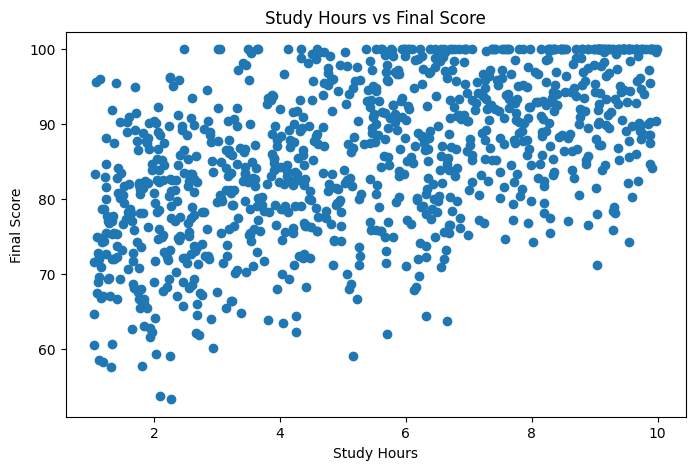

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(data["Study_Hours"], data["Final_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")

plt.show()

#Step-10 : Attendance vs Final Score

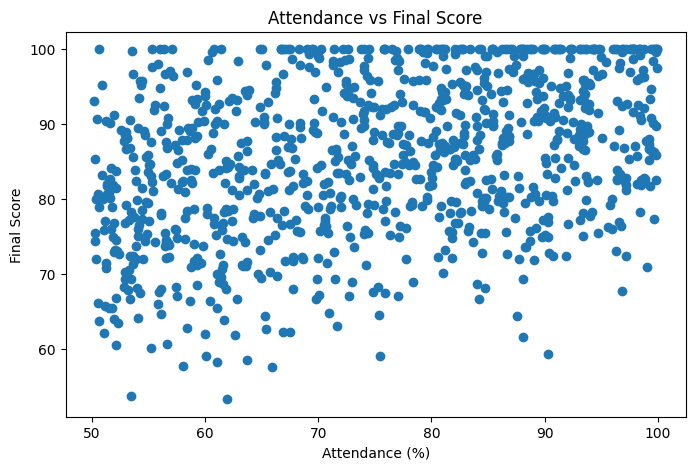

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(data["Attendance"], data["Final_Score"])

plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.title("Attendance vs Final Score")

plt.show()

#Step-11 : Correlation Matrix

In [12]:
correlation = data.corr(numeric_only=True)

print(correlation)

                     Study_Hours  Attendance  Previous_Score  \
Study_Hours             1.000000    0.029310        0.014518   
Attendance              0.029310    1.000000        0.027262   
Previous_Score          0.014518    0.027262        1.000000   
Assignment_Score       -0.029424   -0.005791       -0.013560   
Sleep_Hours             0.034785    0.032911       -0.008858   
Participation_Score    -0.059440    0.029994       -0.020353   
Final_Score             0.551780    0.363021        0.548295   

                     Assignment_Score  Sleep_Hours  Participation_Score  \
Study_Hours                 -0.029424     0.034785            -0.059440   
Attendance                  -0.005791     0.032911             0.029994   
Previous_Score              -0.013560    -0.008858            -0.020353   
Assignment_Score             1.000000    -0.044812             0.039959   
Sleep_Hours                 -0.044812     1.000000            -0.055864   
Participation_Score          0.039959

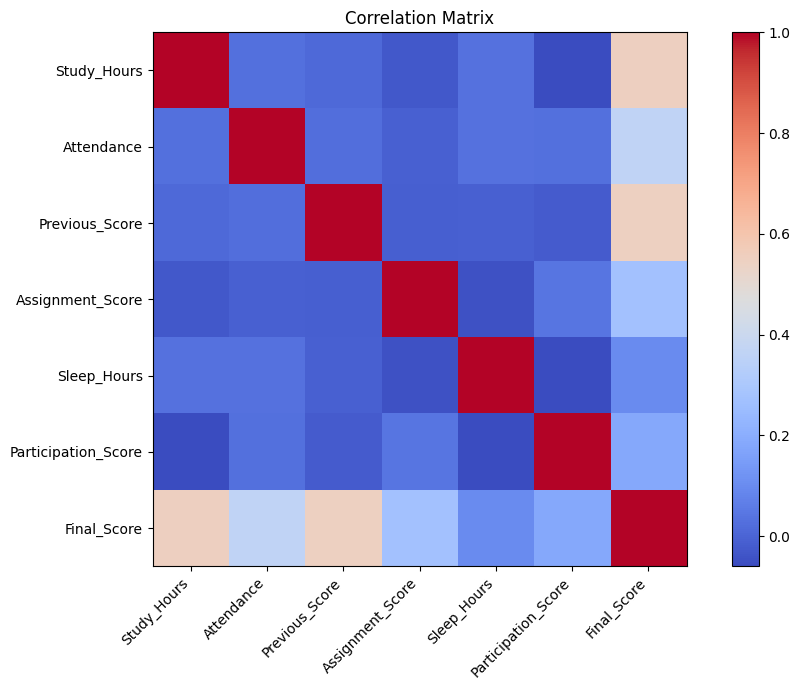

In [13]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

#Step-12 : Separate Input and Output

In [14]:
# Input features
X = data[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Score",
        "Assignment_Score",
        "Sleep_Hours",
        "Participation_Score"
    ]
]

# Target variable
y = data["Final_Score"]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (1000, 6)
Target shape: (1000,)


#Step-13 : Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


#Step-14 : Feature Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


#Step-15 : Build the TensorFlow Neural Network

In [17]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(6,)),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

#Step-16 : Compile the Model

In [18]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully!")

Model compiled successfully!


#Step-17 : Train the Model

In [19]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7435.4648 - mae: 85.6181 - val_loss: 7389.9404 - val_mae: 85.3193
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7276.5640 - mae: 84.6865 - val_loss: 7200.4180 - val_mae: 84.2025
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7034.2983 - mae: 83.2488 - val_loss: 6884.1431 - val_mae: 82.3019
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6633.7095 - mae: 80.8011 - val_loss: 6390.6372 - val_mae: 79.2492
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6040.0635 - mae: 77.0472 - val_loss: 5694.5073 - val_mae: 74.7320
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5233.1245 - mae: 71.6160 - val_loss: 4789.3740 - val_mae: 68.4222
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4233.7803 - mae: 64.2412 - val_loss: 3716.8511 - val_mae: 60.0805
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3115.0430 - mae: 54.8081 - val_loss: 2590.6301 - val_mae: 49

#Step-18 : Plot Training Loss

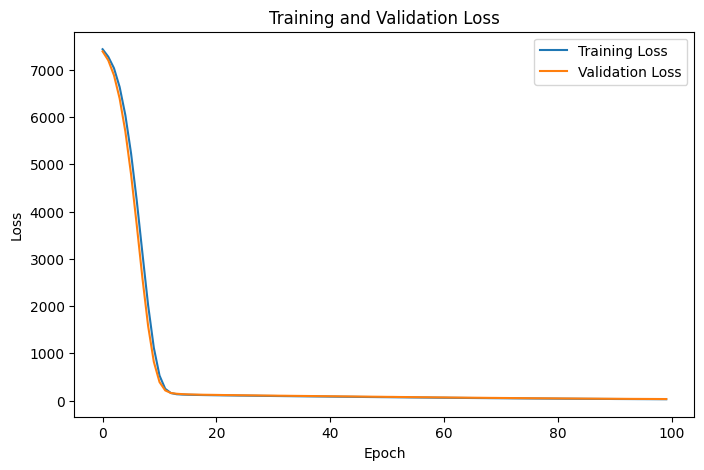

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

#Step-19 : Evaluate the Model

In [21]:
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

Test Loss (MSE): 36.54959487915039
Test MAE: 4.870947360992432


#Step-20 : Generate Predictions

In [22]:
y_pred = model.predict(X_test_scaled)

# Convert predictions from 2D array to 1D array
y_pred = y_pred.flatten()

print("First 10 predictions:")
print(y_pred[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
First 10 predictions:
[78.18016  87.02373  94.55937  72.40681  86.82702  94.22031  68.99257
 94.56877  84.018974 87.13703 ]


#Step-21 : Calculate Regression Metrics

In [23]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

Model Performance
-------------------------
MAE  : 4.870947091487102
MSE  : 36.54959207367314
RMSE : 6.04562586285929
R²   : 0.6689483977550217


#Step-22 : Actual vs Predicted Scores

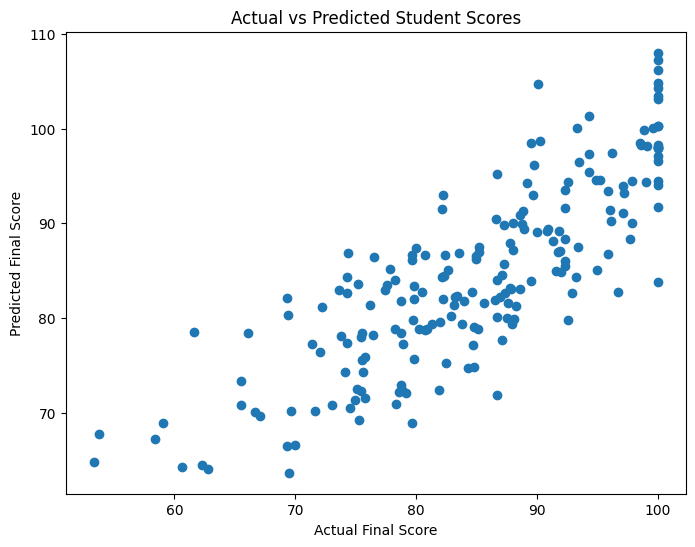

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Student Scores")

plt.show()

#Step-23 : Compare Actual and Predicted Values

In [25]:
comparison = pd.DataFrame({
    "Actual_Score": y_test.values,
    "Predicted_Score": y_pred
})

comparison.head(10)

,Actual_Score,Predicted_Score
0,76.475630,78.180161
1,91.743772,87.023727
2,94.886296,94.559372
3,81.868572,72.406807
4,74.336150,86.827019
5,89.161752,94.220306
6,59.042321,68.992569
7,95.255208,94.568771
8,78.281448,84.018974
9,88.026763,87.137032


#Step-24 : Predict a New Student

In [26]:
# Example new student

new_student = np.array([
    [
        7.0,   # Study Hours
        88.0,  # Attendance
        75.0,  # Previous Score
        82.0,  # Assignment Score
        7.0,   # Sleep Hours
        80.0   # Participation Score
    ]
])

# Scale the new student's data
new_student_scaled = scaler.transform(new_student)

# Make prediction
prediction = model.predict(new_student_scaled)

predicted_score = prediction[0][0]

# Keep prediction within 0-100
predicted_score = np.clip(predicted_score, 0, 100)

print("Predicted Final Score:", round(float(predicted_score), 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Final Score: 90.77


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Step-25 : Make a User Input Predictor

In [29]:
study = float(input("Enter Study Hours per day: "))
attendance_input = float(input("Enter Attendance (%): "))
previous = float(input("Enter Previous Exam Score: "))
assignment = float(input("Enter Assignment Score: "))
sleep = float(input("Enter Average Sleep Hours: "))
participation = float(input("Enter Participation Score: "))

new_student = np.array([[
    study,
    attendance_input,
    previous,
    assignment,
    sleep,
    participation
]])

new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)

predicted_score = np.clip(prediction[0][0], 0, 100)

print("\nPredicted Final Score:", round(float(predicted_score), 2))

Enter Study Hours per day: 8
Enter Attendance (%): 92
Enter Previous Exam Score: 85
Enter Assignment Score: 88
Enter Average Sleep Hours: 7
Enter Participation Score: 90
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Predicted Final Score: 100.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Step-26 : Saving the TensorFlow Model

In [30]:
model.save("student_performance_model.keras")

print("Model saved successfully!")

Model saved successfully!


#Step-27 : Downloading the Dataset

In [31]:
from google.colab import files

files.download("student_performance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# Step-28 : Download Trained Model

from google.colab import files

files.download("student_performance_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# Step-29 : Final Project Check

print("===== Final Project Check =====")

print("Dataset size       :", num_students)
print("Training samples   :", X_train.shape[0])
print("Testing samples    :", X_test.shape[0])
print("Input features     :", X_train.shape[1])
print("Model type         : TensorFlow Neural Network")
print("Output type        : Numerical Score (Regression)")
print("Model file         : student_performance_model.keras")
print("Dataset file       : student_performance.csv")

print("\nProject completed successfully!")

===== Final Project Check =====
Dataset size       : 1000
Training samples   : 800
Testing samples    : 200
Input features     : 6
Model type         : TensorFlow Neural Network
Output type        : Numerical Score (Regression)
Model file         : student_performance_model.keras
Dataset file       : student_performance.csv

Project completed successfully!
